### Autoencoder

An autoencoder is an unsupervised learning technique for neural networks that learns efficient data representations (encoding) by training the network to ignore signal “noise.” Autoencoders can be used for image denoising, image compression, and, in some cases, even generation of image data.

### Flow of Autoencoder

Noisy Image -> Encoder -> Compressed Representation -> Decoder -> Reconstruct Clear Image

### Import Modules

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from keras import Sequential 
from keras.layers import Dense, Conv2D, MaxPooling2D, UpSampling2D
from keras.datasets import mnist

### Load the Dataset

In [3]:
(x_train, _),(x_test, _) = mnist.load_data()

In [4]:
#normalize the image data

x_train = x_train.astype("float") / 255
x_test = x_test.astype("float") / 255

In [5]:
#reshape in the input data for the model

x_train = x_train.reshape(len(x_train),28,28,1)
x_test = x_test.reshape(len(x_test),28,28,1)
x_test.shape

(10000, 28, 28, 1)

### Add Noise to the image 

In [6]:
#add noise

noise_factor = 0.6
x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0,scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

In [7]:
#clip the values in the range of 0 - 1

x_train_noisy = np.clip(x_train_noisy, 0.,1.)
x_test_noisy = np.clip(x_test_noisy, 0.,1.)

### Exploratory Data Analysis

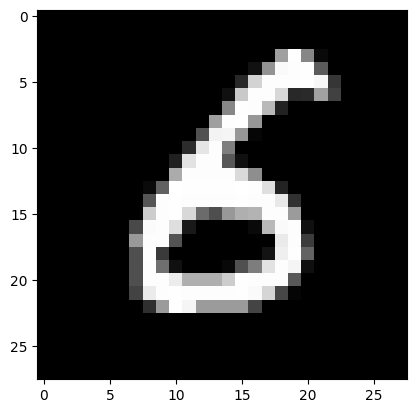

In [8]:
#randomly select input image
index = np.random.randint(len(x_test))
#plot the image
plt.imshow(x_test[index].reshape(28,28))
plt.gray()

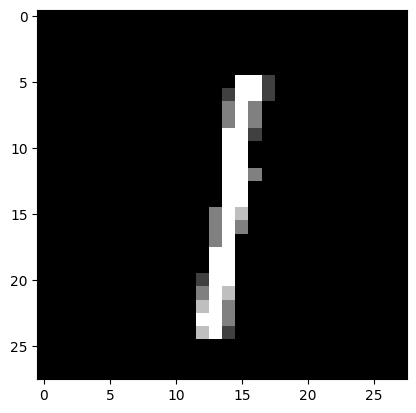

In [13]:
index = np.random.randint(len(x_test))
plt.imshow(x_test[index].reshape(28,28)) 
plt.gray()

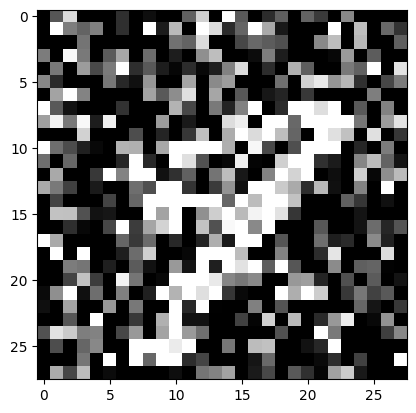

In [12]:
index = np.random.randint(len(x_test))
plt.imshow(x_test_noisy[index].reshape(28,28))
plt.gray()

### Model Creation

In [15]:
model = Sequential()
model.add(Conv2D(32, 3, activation="relu",padding="same",input_shape=(28,28,1)))
model.add(MaxPooling2D(2,padding="same"))
model.add(Conv2D(16, 3, activation="relu",padding="same"))
model.add(MaxPooling2D(2,padding="same"))
#decoder network
model.add(Conv2D(16,3,activation="relu",padding="same"))
model.add(UpSampling2D(2))
Conv2D(32,3,activation="relu",padding="same")
model.add(UpSampling2D(2))
#Output Layer
model.add(Conv2D(1,3,activation="sigmoid",padding="same"))

In [16]:
model.compile(
    optimizer="adam",
    loss = "binary_crossentropy",
    metrics = ["accuracy"]
)

In [17]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 28, 28, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 14, 14, 16)          │           4,624 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 7, 7, 16)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 7, 7, 16)            │           2,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling2d (UpSampling2D)         │ (None, 14, 14, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling2d_1 (UpSampling2D)       │ (None, 28, 28, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 28, 28, 1)           │             145 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,409 (28.94 KB)

 Trainable params: 7,409 (28.94 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
model.fit(x_train_noisy,x_train, epochs=20,batch_size=256,validation_data=(x_test_noisy,x_test))

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 27s 105ms/step - accuracy: 0.7614 - loss: 0.1732 - val_accuracy: 0.8072 - val_loss: 0.0063
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 27s 116ms/step - accuracy: 0.8091 - loss: 0.0053 - val_accuracy: 0.8072 - val_loss: 0.0043
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 26s 109ms/step - accuracy: 0.8086 - loss: 0.0042 - val_accuracy: 0.8072 - val_loss: 0.0042
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 21s 90ms/step - accuracy: 0.8089 - loss: 0.0042 - val_accuracy: 0.8072 - val_loss: 0.0042
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 21s 91ms/step - accuracy: 0.8090 - loss: 0.0042 - val_accuracy: 0.8072 - val_loss: 0.0042
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 22s 94ms/step - accuracy: 0.8087 - loss: 0.0042 - val_accuracy: 0.8072 - val_loss: 0.0042
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 21s 91ms/step - accuracy: 0.8088 - loss: 0.0041 - val_accuracy: 0.8072 - val_loss: 0.0042
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 21s 90ms/step - accuracy: 0.8088 - loss: 0.0041

### Visualize the Result

In [20]:
pred = model.predict(x_test_noisy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step 


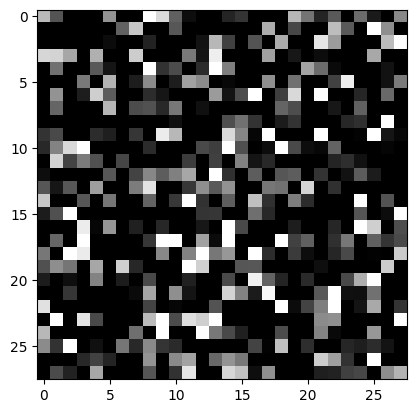

In [21]:
index = np.random.randint(len(x_test))
plt.imshow(x_test_noisy[index].reshape(28,28))
plt.gray()

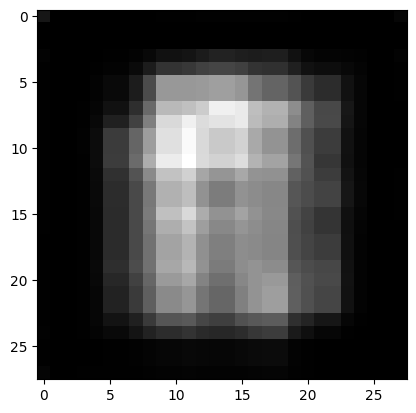

In [22]:
plt.imshow(pred[index].reshape(28,28))
plt.gray()

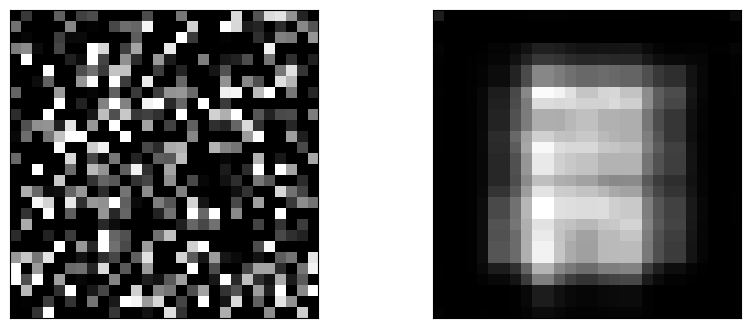

In [23]:
index = np.random.randint(len(x_test))
plt.figure(figsize=(10, 4))
# display original image
ax = plt.subplot(1, 2, 1)
plt.imshow(x_test_noisy[index].reshape(28,28))
plt.gray()
ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)
# display compressed image
ax = plt.subplot(1, 2, 2)
plt.imshow(pred[index].reshape(28,28))
plt.gray()
ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)
plt.show()
     

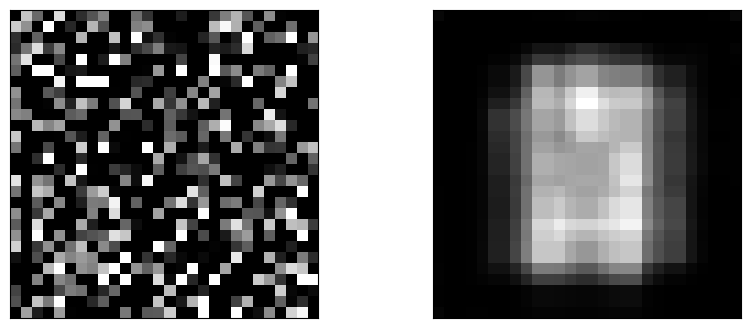

In [24]:
index = np.random.randint(len(x_test))
plt.figure(figsize=(10, 4))
# display original image
ax = plt.subplot(1, 2, 1)
plt.imshow(x_test_noisy[index].reshape(28,28))
plt.gray()
ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)
# display compressed image
ax = plt.subplot(1, 2, 2)
plt.imshow(pred[index].reshape(28,28))
plt.gray()
ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)
plt.show()